Pb 1 - realizati subesantionarea pe fiecare plan de culoare cu pasul 4. Dupa esantionare aplicati o transformare neliniara cu gamma = 0.45 fiecarui plan de culoare

uint8
(466, 701, 4)


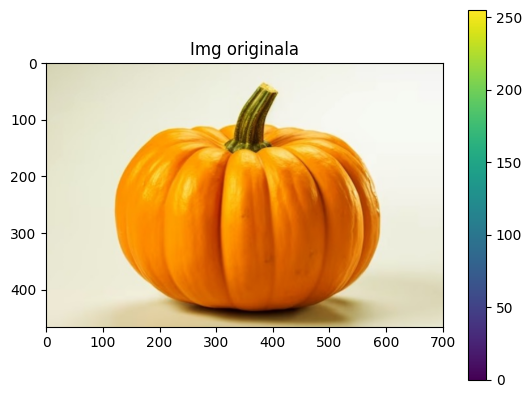

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0856325717452218..1.4988451640768823].


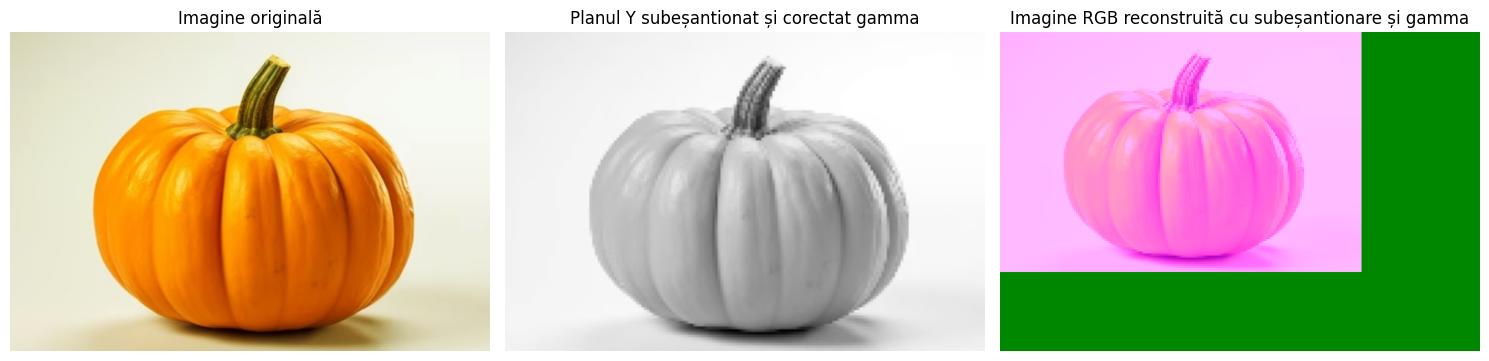

In [8]:
import numpy as np
from skimage import io, color
from skimage.util import img_as_float
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import signal

# Citirea imaginii
img = io.imread('dovleac.png')

# Tipul de date al imaginii originale, truecolor
print(img.dtype)
print(img.shape)

img = img[:,:,0:3]

# Afisarea imaginii
plt.figure(), plt.imshow(img),plt.title("Img originala"), plt.colorbar(), plt.show()

import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color

def subsample_classic(plan, factor=2):
    """
    Realizează o subeșantionare clasică prin reducerea rezoluției planului de culoare.

    :param plan: Planul de culoare (Cb, Cr sau Y) sub forma unei matrice 2D.
    :param factor: Factorul de reducere a rezoluției (implicit 2).
    :return: Planul subeșantionat (rezoluție redusă).
    """
    H, W = plan.shape
    # Subeșantionare prin selectarea unui pixel din fiecare bloc de `factor x factor`
    return plan[::factor, ::factor]

def upsample(plan, original_shape):
    """
    Realizează o supraeșantionare prin interpolare simplă pentru a reveni la dimensiunea inițială.

    :param plan: Planul subeșantionat (rezoluție redusă).
    :param original_shape: Forma originală a planului.
    :return: Planul cu rezoluția restaurată (supraeșantionat).
    """
    H, W = original_shape
    upsampled = np.zeros((H, W))

    factor_h = H // plan.shape[0]
    factor_w = W // plan.shape[1]

    for i in range(plan.shape[0]):
        for j in range(plan.shape[1]):
            upsampled[i*factor_h:(i+1)*factor_h, j*factor_w:(j+1)*factor_w] = plan[i, j]

    return upsampled

def apply_gamma_correction(plan, gamma):
    """
    Aplică o corecție gamma neliniară unui plan de culoare.

    :param plan: Planul de culoare (Cb, Cr sau Y) sub forma unei matrice 2D.
    :param gamma: Valoarea gamma pentru transformare.
    :return: Planul cu corecția gamma aplicată.
    """
    return np.power(plan / 255.0, gamma) * 255

# Imagine de test

img_ycbcr = color.rgb2ycbcr(img)

# Separăm planurile
Y = img_ycbcr[:, :, 0]
Cb = img_ycbcr[:, :, 1]
Cr = img_ycbcr[:, :, 2]

# Aplicăm subeșantionarea cu factor 4 pe fiecare plan
Y_subsampled = subsample_classic(Y, factor=4)
Cb_subsampled = subsample_classic(Cb, factor=4)
Cr_subsampled = subsample_classic(Cr, factor=4)

# Aplicăm corecția gamma cu gamma = 0.45
Y_gamma = apply_gamma_correction(Y_subsampled, gamma=0.45)
Cb_gamma = apply_gamma_correction(Cb_subsampled, gamma=0.45)
Cr_gamma = apply_gamma_correction(Cr_subsampled, gamma=0.45)

# Supraeșantionăm pentru a reveni la dimensiunea inițială
Y_restored = upsample(Y_gamma, Y.shape)
Cb_restored = upsample(Cb_gamma, Cb.shape)
Cr_restored = upsample(Cr_gamma, Cr.shape)

# Reconstruim imaginea cu planurile restaurate
img_ycbcr[:, :, 0] = Y_restored
img_ycbcr[:, :, 1] = Cb_restored
img_ycbcr[:, :, 2] = Cr_restored
img_reconstructed = color.ycbcr2rgb(img_ycbcr)

# Afișăm rezultatele
plt.figure(figsize=(15, 10))
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Imagine originală")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(Y_gamma, cmap='gray')
plt.title("Planul Y subeșantionat și corectat gamma")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_reconstructed)
plt.title("Imagine RGB reconstruită cu subeșantionare și gamma")
plt.axis("off")

plt.tight_layout()
plt.show()





Pb 2 - Creati o functie care sa afecteze 5% dintr-o imagine cu zgomot impulsiv, apoi filtrati imaginea cu ajutorul filtrul median marginal cu o fereastra 5x5 px

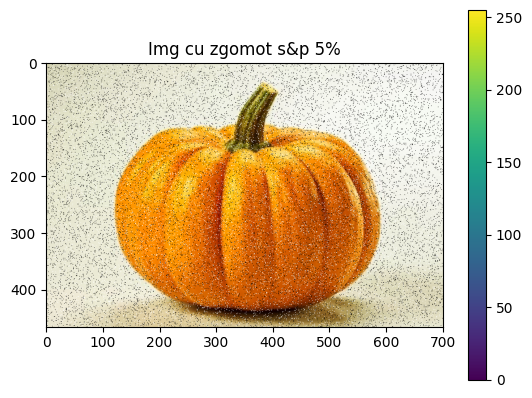

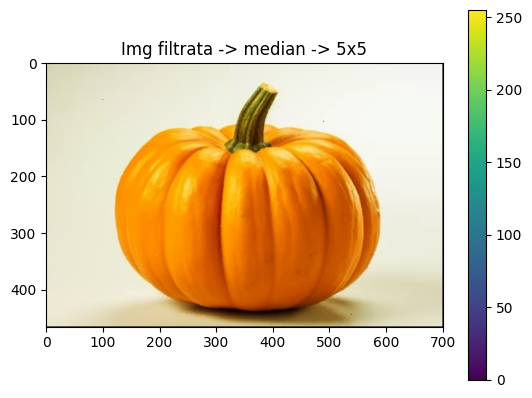

(<Figure size 640x480 with 2 Axes>,
 Text(0.5, 1.0, 'Img filtrata -> median -> 5x5'),
 None)

In [13]:
def add_sp_noise(img, p0, p255):
    h, w, c = img.shape
    img_out = img.copy()
    nr_px_0 = int(np.floor(p0 * h * w))
    nr_px_255 = int(np.floor(p255 * h * w))
    coords = np.random.randint(0, high=[h, w], size=(nr_px_0 + nr_px_255, 2))
    img_out[coords[:nr_px_0, 0], coords[:nr_px_0, 1], :] = 0
    img_out[coords[nr_px_0:, 0], coords[nr_px_0:, 1], :] = 255
    return img_out

def median_filter(img, dim_fereastra):
    h, w, c = img.shape
    img_out = np.zeros_like(img, dtype=np.uint8)
    offset = dim_fereastra // 2
    for y in range(offset, h - offset):
        for x in range(offset, w - offset):
            for channel in range(c):
                patch = img[y - offset:y + offset + 1, x - offset:x + offset + 1, channel]
                img_out[y, x, channel] = np.median(patch)
    return img_out

zg_sp = add_sp_noise(img, p0=0.05, p255=0.05)
plt.figure(), plt.imshow(zg_sp),plt.title("Img cu zgomot s&p 5%"), plt.colorbar(), plt.show()
filtered_sp_median = median_filter(zg_sp, dim_fereastra=3)
plt.figure(), plt.imshow(filtered_sp_median),plt.title("Img filtrata -> median -> 5x5"), plt.colorbar(), plt.show()


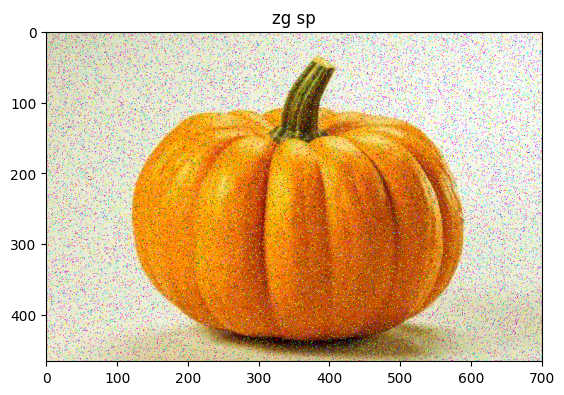

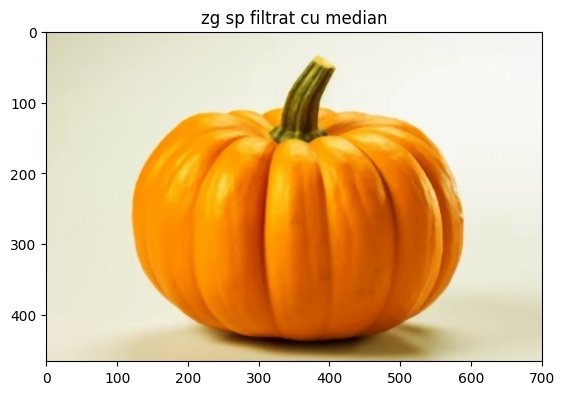

(<Figure size 640x480 with 1 Axes>,
 Text(0.5, 1.0, 'zg sp filtrat cu median'),
 None)

In [16]:
# varianta 2
def median_scalar(img, dim):
    if(np.max(img)>1):
        img = img/255.0
    [L,C] = np.shape(img)
    kernel = np.zeros((dim, dim))
    poz_median = dim*dim//2
    W = dim//2
    kernel[W,W] = 1
    Ybordat = signal.convolve2d(img, kernel, mode='full', boundary = 'symm')
    imgout = np.zeros((L,C))
    for l in range (0, L):
        for c in range (0, C):
            #selecteaza valori conform ferestri plasate (l,c)
            val_selectate = Ybordat[l-W+W:l+W+1+W, c-W+W:c+W+1+W]
            #combina valorile selectate
            val_sortate = np.sort(np.ndarray.flatten(val_selectate))
            #scrie rezultatul in imgout[l,c]
            imgout[l,c]=val_sortate[poz_median]
    return imgout

def median_marginal(img, dim):
    if(np.max(img)>1):
        img = img/255.0
    [L,C,pl] = np.shape(img)
    imgout = np.zeros((L,C,pl))
    for p in range (0, pl):
        imgout[:,:,p] = median_scalar(img[:,:,p], dim)

    return imgout

def add_impulsive_noise(img, p0, p1):  # p0 si p1 sunt probabilitati
    if np.max(img) > 1:  # normalizam la intervalul [0, 1]
        img = img / 255.0
    [L, C, pl] = np.shape(img)
    Nrpix0 = int(L * C * p0)
    Nrpix1 = int(L * C * p1)

    for plan_curent in range(0, pl):
        numere_intregiL = np.random.randint(0, L, [Nrpix0])
        numere_intregiC = np.random.randint(0, C, [Nrpix0])
        img[numere_intregiL, numere_intregiC, plan_curent] = 0

        numere_intregiL = np.random.randint(0, L, [Nrpix1])
        numere_intregiC = np.random.randint(0, C, [Nrpix1])
        img[numere_intregiL, numere_intregiC, plan_curent] = 1

    return img

imgzg_imp = add_impulsive_noise(img, 0.05, 0.05)
plt.figure(), plt.imshow(imgzg_imp), plt.title("zg s&p 5%"), plt.show()

imgfiltrat_med = median_marginal(imgzg_imp,5)
plt.figure(), plt.imshow(imgfiltrat_med), plt.title("zg s&p filtrat cu median"), plt.show()

Pb 3 - Realizati segmentarea pe planul de luminanta a obiectului principal folosind cel putin 2 praguri

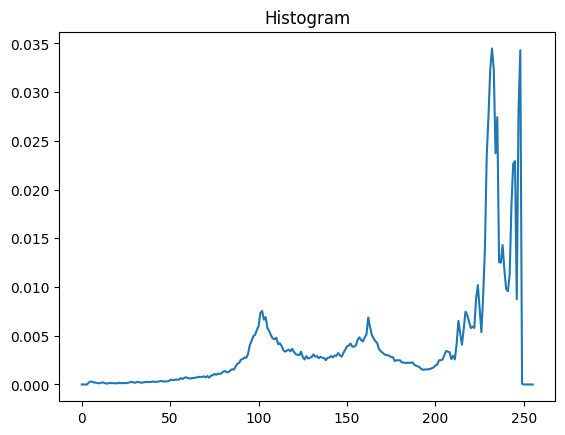

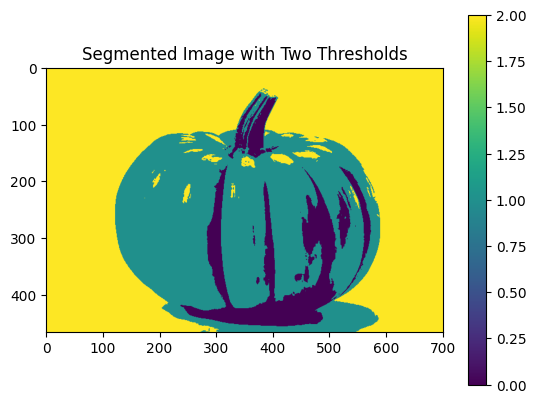

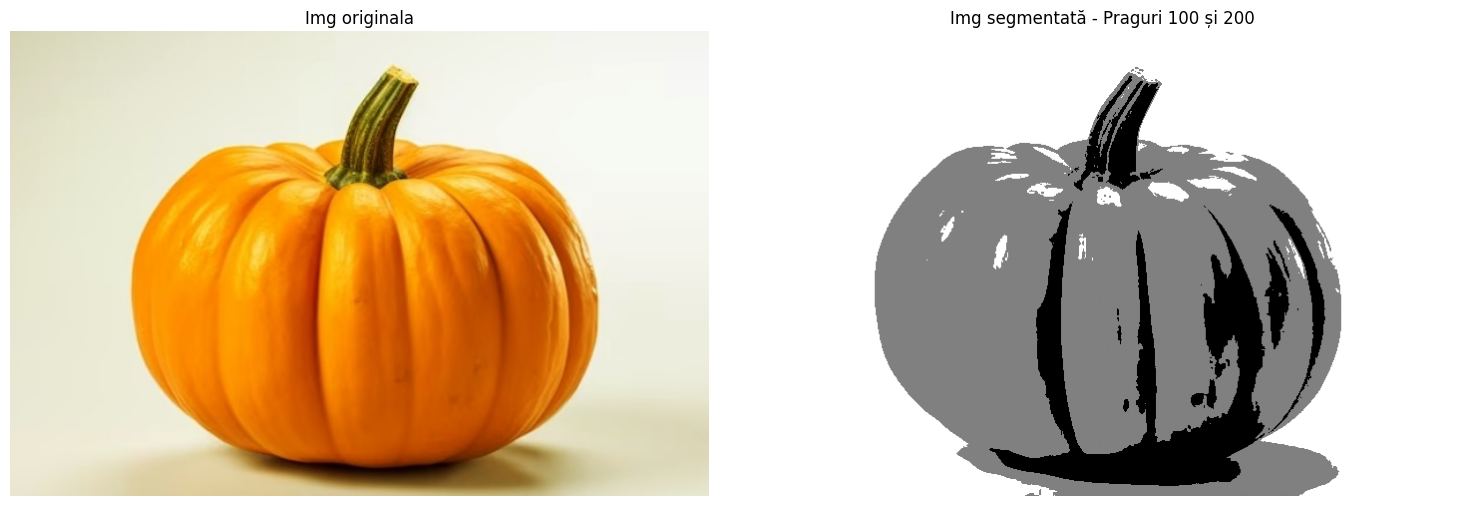

In [18]:
# Funcție pentru segmentarea pe histograma imaginii cu două praguri
def histogram_segmentation_two_thresholds(img, T1, T2):
    Y = np.uint8(255 * color.rgb2gray(img))  # Conversie în grayscale și scalare

    # Calculul histogramei normalizate
    hist, _ = np.histogram(Y, bins=256, range=(0, 256))
    hist = hist / np.sum(hist)

    # Afișarea histogramei
    plt.figure(), plt.plot(hist), plt.title("Histogram"), plt.show()

    # Segmentare folosind două praguri
    [Linii, Coloane] = np.shape(Y)
    out = np.zeros((Linii, Coloane))

    for l in range(0, Linii):
        for c in range(0, Coloane):
            if Y[l, c] > T2:  # Pragul superior
                out[l, c] = 2
            elif Y[l, c] > T1:  # Pragul inferior
                out[l, c] = 1

    # Afișarea rezultatului
    plt.figure(), plt.imshow(out, interpolation=None), plt.colorbar(), plt.title("Segmented Image with Two Thresholds"), plt.show()

    return out

# Imagine de test
img = io.imread('dovleac.png')
img = img[:, :, :3]  # Eliminăm canalul alfa, dacă există

# Segmentarea pe histograma imaginii balansate cu două praguri
segmented_two_thresholds = histogram_segmentation_two_thresholds(img, 100, 200) # prag1 = 100, prag2 = 200

# Afișarea rezultatelor
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].imshow(img)
axs[0].set_title("Img originala")
axs[0].axis("off")

axs[1].imshow(segmented_two_thresholds, cmap='gray')
axs[1].set_title("Img segmentată - Praguri 100 și 200")
axs[1].axis("off")

plt.tight_layout()
plt.show()

Pb 4 - Realizati balansul de alb prin metoda cel mai stralucitor obiect este alb, folosind ca referinta maximul de pe planul de luminanta

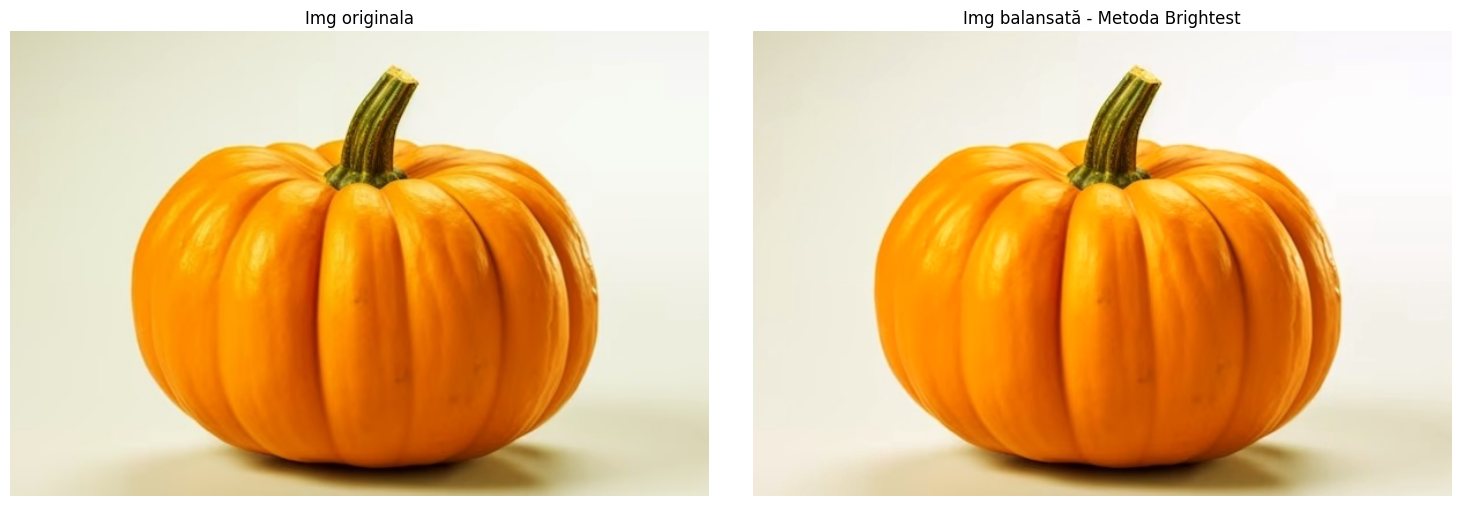

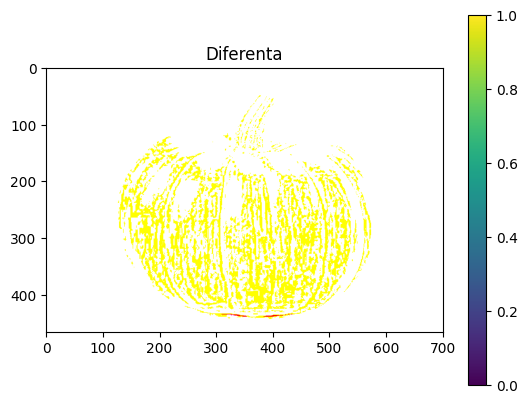

(<Figure size 640x480 with 2 Axes>,
 Text(0.5, 1.0, 'Diferenta'),
 None)

In [23]:
def white_balance_brightest(img):
    if np.max(img) > 1:
        img = img / 255.0  # Normalizare în intervalul [0, 1]

    # Convertim imaginea în spațiul YCbCr pentru a găsi luminozitatea maximă
    img_ycbcr = np.zeros_like(img)
    img_ycbcr[:, :, 0] = 0.299 * img[:, :, 0] + 0.587 * img[:, :, 1] + 0.114 * img[:, :, 2]  # Canal Y
    img_ycbcr[:, :, 1] = 128 + (-0.1687 * img[:, :, 0] - 0.3313 * img[:, :, 1] + 0.5 * img[:, :, 2])  # Canal Cb
    img_ycbcr[:, :, 2] = 128 + (0.5 * img[:, :, 0] - 0.4187 * img[:, :, 1] - 0.0813 * img[:, :, 2])  # Canal Cr

    # Găsim indicele pixelului cel mai strălucitor din imagine (Y maxim)
    Y = img_ycbcr[:, :, 0]
    ind = np.unravel_index(np.argmax(Y, axis=None), Y.shape)

    # Extragem valorile maxime pentru canalele R, G și B
    Rmax = img[ind[0], ind[1], 0]
    Gmax = img[ind[0], ind[1], 1]
    Bmax = img[ind[0], ind[1], 2]

    # Ajustarea balansului de alb prin normalizare la valorile maxime
    img[:, :, 0] = img[:, :, 0] / Rmax
    img[:, :, 1] = img[:, :, 1] / Gmax
    img[:, :, 2] = img[:, :, 2] / Bmax

    # Clipăm valorile pentru a rămâne în intervalul [0, 1]
    img_balanced = np.clip(img, 0, 1)
    return img_balanced

# Aplicarea balansului de alb
img_balanced = white_balance_brightest(img)

# Afișarea rezultatelor
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].imshow(img)
axs[0].set_title("Img originala")
axs[0].axis("off")

axs[1].imshow(img_balanced)
axs[1].set_title("Img balansată - Metoda Brightest")
axs[1].axis("off")

plt.tight_layout()
plt.show()

diff = np.float64(img[:,:,0:3]) - np.float64(img_balanced)
plt.figure(), plt.imshow(np.clip(diff, 0, 1)), plt.colorbar(), plt.title("Diferenta"), plt.show()

Pb 5 - Extrageti muchiile folosind nucleele Sobel

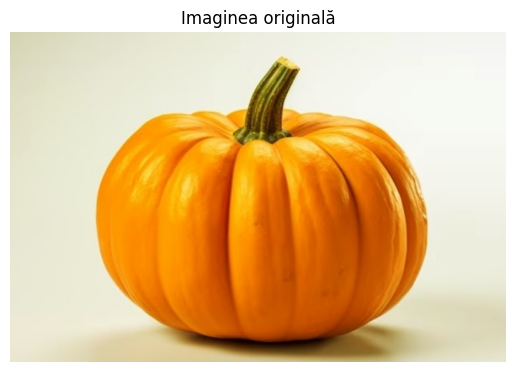

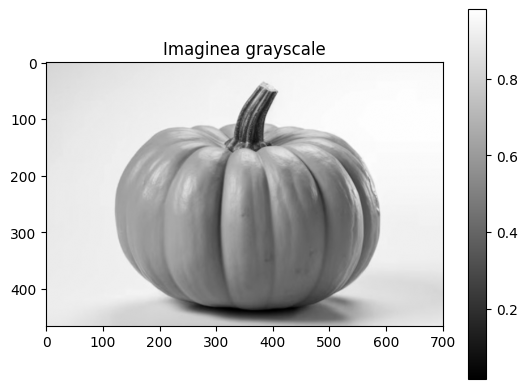

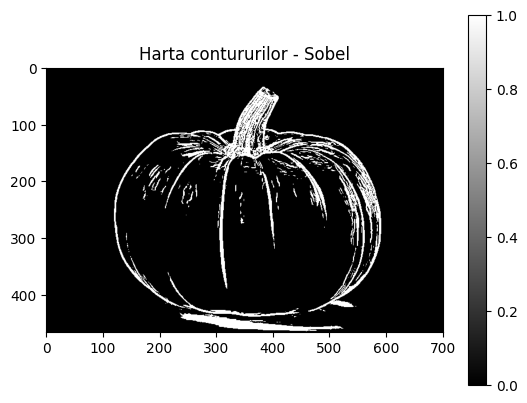

In [25]:
# Funcție pentru extragerea contururilor utilizând gradient Sobel
def extract_sobel_contours(img):
    # Conversia imaginii în grayscale
    Y = color.rgb2gray(img)

    # Kernel Sobel orizontal
    kernelH = np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ])

    # Kernel Sobel vertical
    kernelV = np.array([
        [-1, -2, -1],
        [ 0,  0,  0],
        [ 1,  2,  1]
    ])

    # Aplicarea convoluției
    YH = signal.convolve2d(Y, kernelH, mode='same', boundary='symm')
    YV = signal.convolve2d(Y, kernelV, mode='same', boundary='symm')

    # Calcularea hărții de intensitate a contururilor
    contur_map = np.sqrt(YH**2 + YV**2)

    # Afișarea rezultatelor
    plt.figure(), plt.imshow(img), plt.title("Imaginea originală"), plt.axis("off"), plt.show()
    plt.figure(), plt.imshow(Y, cmap='gray'), plt.title("Imaginea grayscale"), plt.colorbar(), plt.show()
    plt.figure(), plt.imshow(contur_map >= 0.2, cmap='gray'), plt.title("Harta contururilor - Sobel"), plt.colorbar(), plt.show()

    return contur_map

contour_map_sobel = extract_sobel_contours(img)